In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

url = "https://raw.githubusercontent.com/dhieu0901/DSEB65A_MachineLearningProject_Group5/main/data/Hanoi%20Daily%2010%20years.csv"

df = pd.read_csv(url)

print("Kích thước dữ liệu (Rows, Columns):", df.shape)
print("\n5 dòng dữ liệu đầu tiên:")
print(df.head())

Kích thước dữ liệu (Rows, Columns): (3660, 33)

5 dòng dữ liệu đầu tiên:
    name   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  Hanoi  9/20/2015     33.0     26.7  29.3          41.7          30.5   
1  Hanoi  9/21/2015     29.5     25.0  26.8          34.4          25.0   
2  Hanoi  9/22/2015     28.5     25.0  25.9          32.8          25.0   
3  Hanoi  9/23/2015     31.3     25.5  28.0          39.7          25.5   
4  Hanoi  9/24/2015     34.5     26.5  29.9          43.5          26.5   

   feelslike   dew  humidity  ...  solarenergy  uvindex  severerisk  \
0       35.4  25.7      81.5  ...         12.2        5         NaN   
1       29.2  24.3      86.3  ...          5.8        3         NaN   
2       26.5  24.2      90.5  ...          7.2        3         NaN   
3       32.0  25.4      86.2  ...         12.1        5         NaN   
4       36.4  25.9      80.4  ...         19.5        8         NaN   

               sunrise               sunset  moon

In [5]:
print("\nThông tin về các cột (Dtype & Non-Null Counts):")
df.info()


Thông tin về các cột (Dtype & Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3660 non-null   object 
 1   datetime          3660 non-null   object 
 2   tempmax           3660 non-null   float64
 3   tempmin           3660 non-null   float64
 4   temp              3660 non-null   float64
 5   feelslikemax      3660 non-null   float64
 6   feelslikemin      3660 non-null   float64
 7   feelslike         3660 non-null   float64
 8   dew               3660 non-null   float64
 9   humidity          3660 non-null   float64
 10  precip            3660 non-null   float64
 11  precipprob        3660 non-null   int64  
 12  precipcover       3660 non-null   float64
 13  preciptype        2673 non-null   object 
 14  snow              3660 non-null   int64  
 15  snowdepth         3660 non-null   int64 

In [6]:
print("\nThống kê mô tả (Chỉ các cột số):")
print(df.describe().T)


Thống kê mô tả (Chỉ các cột số):
                   count         mean        std    min       25%        50%  \
tempmax           3660.0    28.460519   5.810885    8.0    24.100    29.4000   
tempmin           3660.0    21.882814   4.857733    5.9    18.000    23.0000   
temp              3660.0    24.844426   5.111883    7.0    21.000    26.0000   
feelslikemax      3660.0    32.541011   9.518917    8.0    24.100    32.7000   
feelslikemin      3660.0    22.636202   6.047288    2.1    18.000    23.0000   
feelslike         3660.0    27.320355   7.712572    4.6    21.000    26.9000   
dew               3660.0    20.432158   5.841853   -2.0    16.700    22.4000   
humidity          3660.0    78.259235  10.907329   31.0    72.100    79.9000   
precip            3660.0     5.231195  16.031570    0.0     0.000     0.2175   
precipprob        3660.0    71.912568  44.948764    0.0     0.000   100.0000   
precipcover       3660.0     8.134426  10.574178    0.0     0.000     4.1700   
snow  

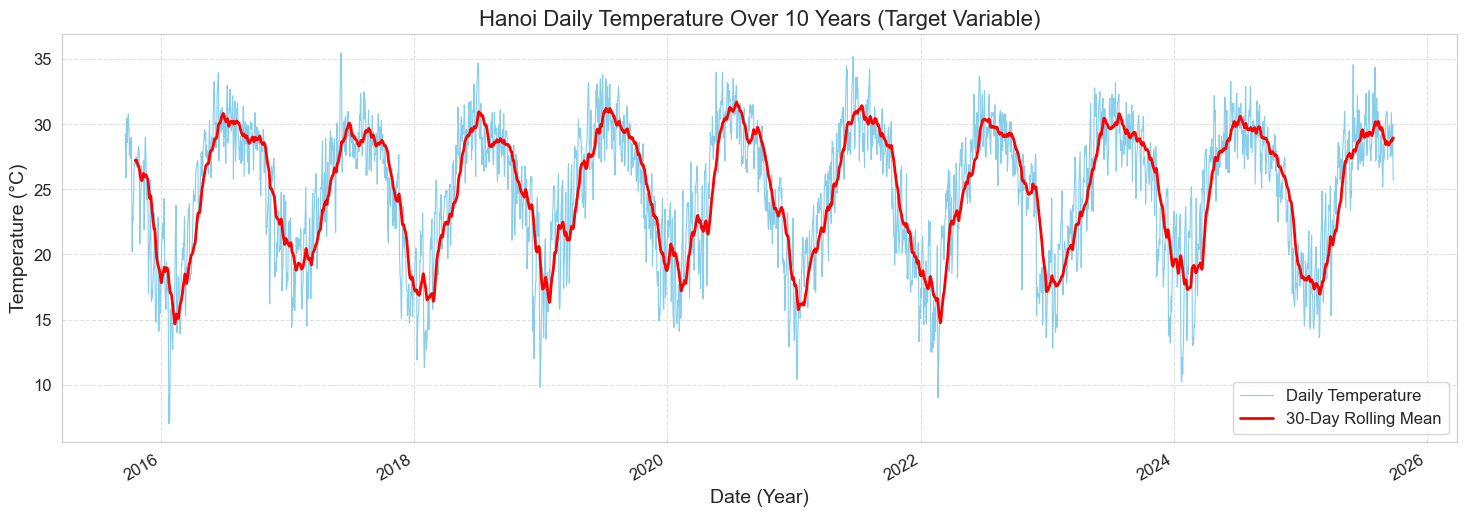

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

plt.figure(figsize=(18, 6))
plt.plot(df.index, df['temp'], label='Daily Temperature', color='skyblue', linewidth=0.8)

df['temp'].rolling(window=30).mean().plot(label='30-Day Rolling Mean', color='red', linewidth=2)

plt.title('Hanoi Daily Temperature Over 10 Years (Target Variable)', fontsize=16)
plt.xlabel('Date (Year)', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Thống kê về Nhiệt độ (temp):
count    3660.000000
mean       24.844426
std         5.111883
min         7.000000
25%        21.000000
50%        26.000000
75%        28.900000
max        35.500000
Name: temp, dtype: float64


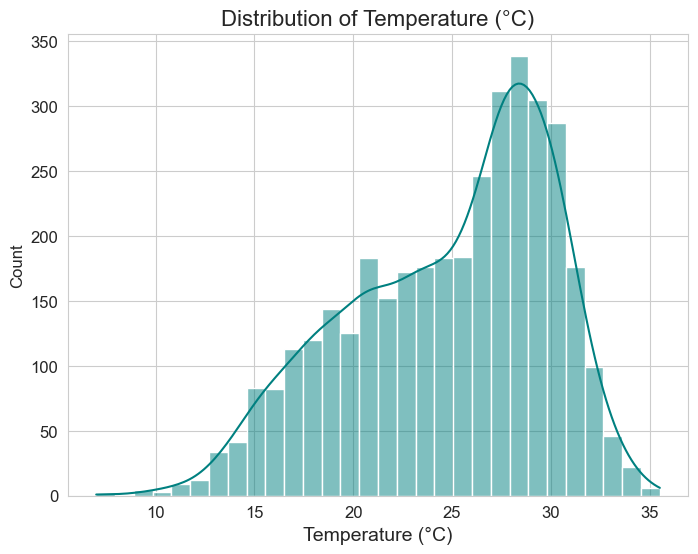

In [9]:
print("\nThống kê về Nhiệt độ (temp):")
print(df['temp'].describe())

# Quan sát về sự phân bố
plt.figure(figsize=(8, 6))
sns.histplot(df['temp'], kde=True, bins=30, color='teal')
plt.title('Distribution of Temperature (°C)', fontsize=16)
plt.xlabel('Temperature (°C)', fontsize=14)
plt.show()

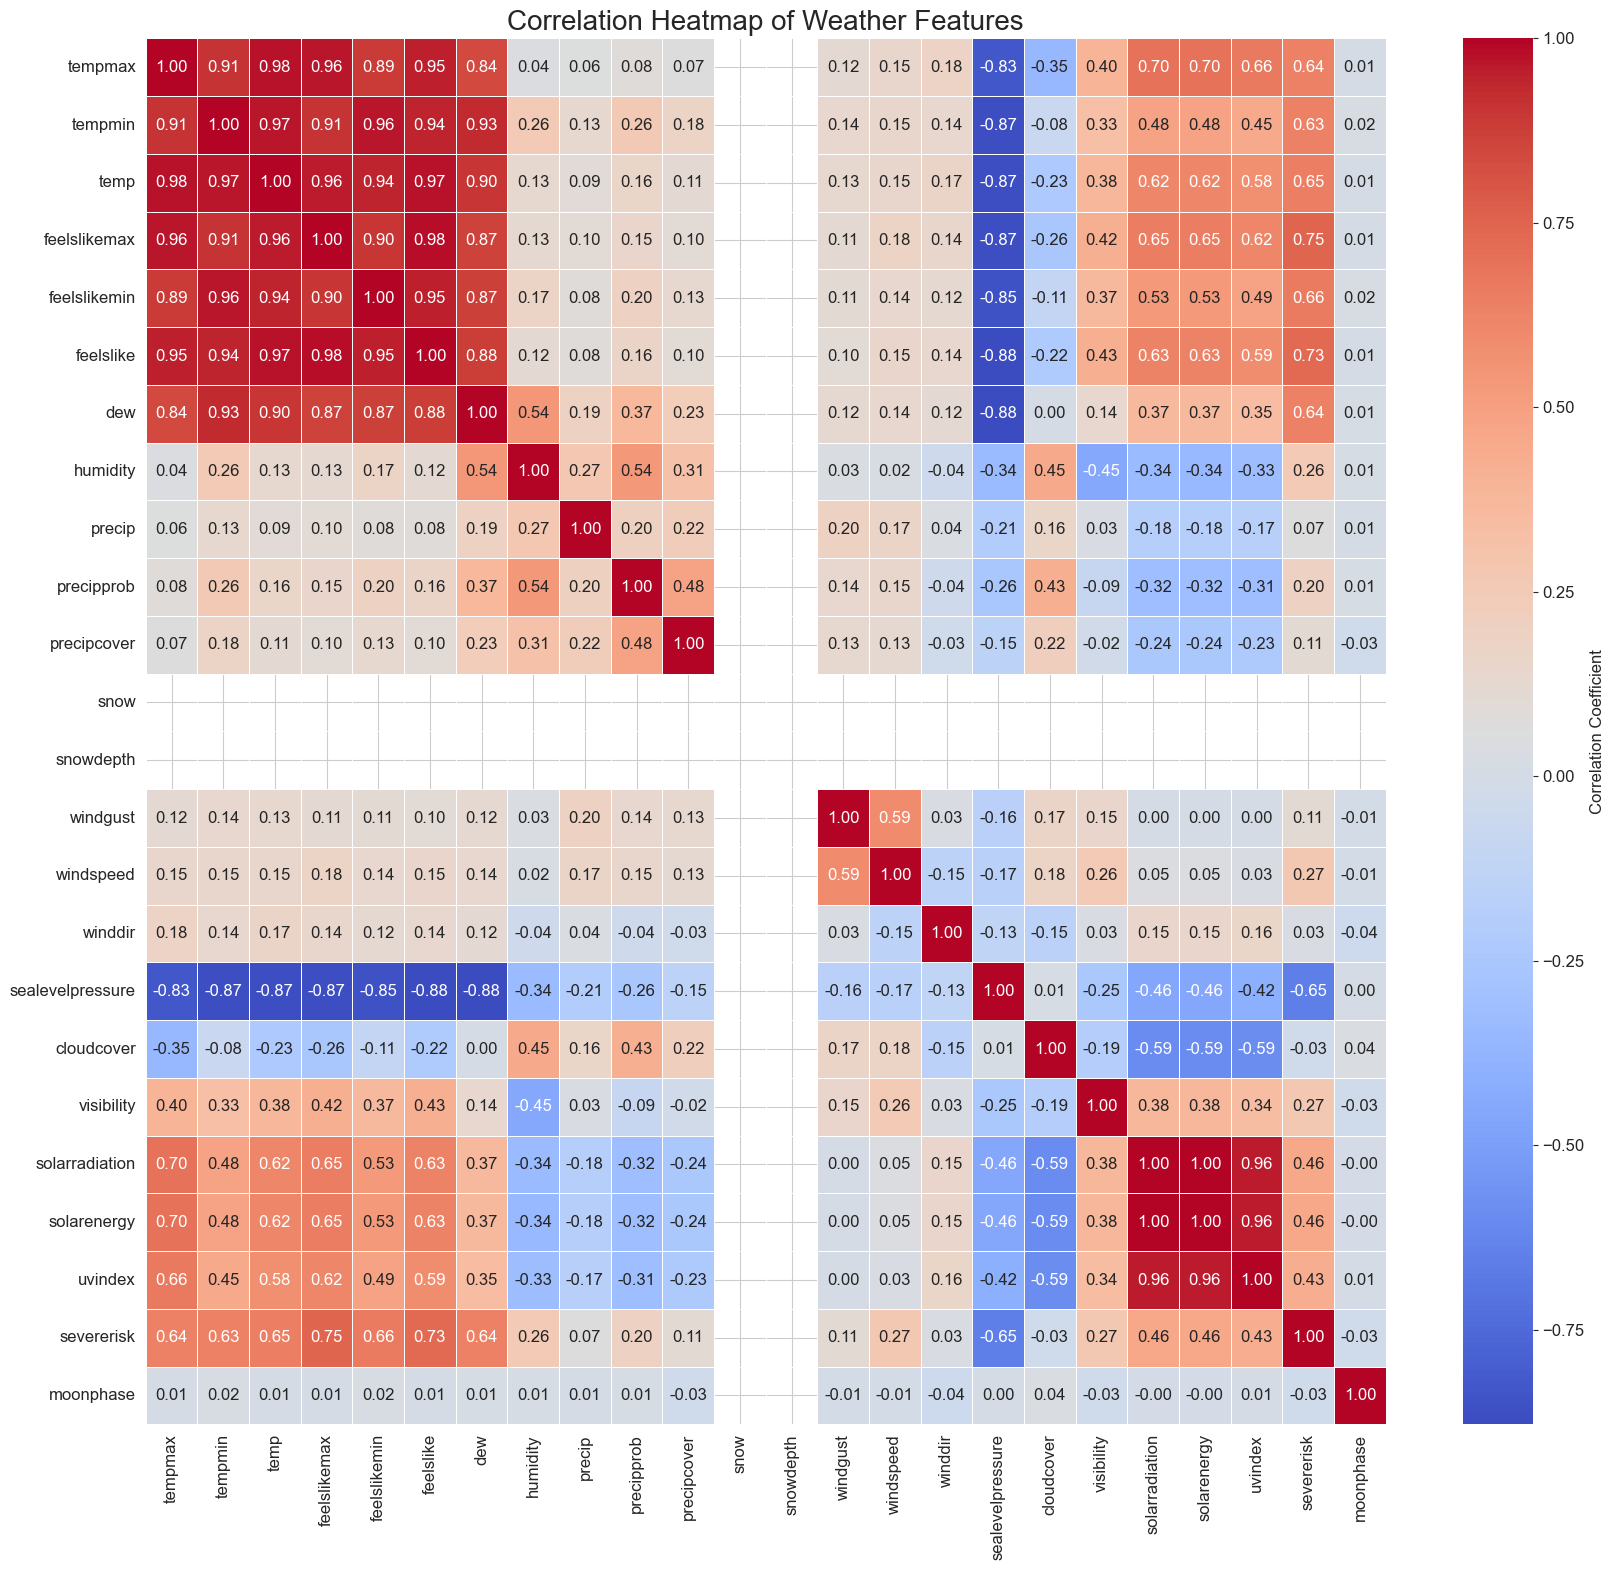

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(
    correlation_matrix, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Weather Features', fontsize=20)
plt.show()


Mối tương quan của các Features với Nhiệt độ (temp):
temp                1.000000
tempmax             0.977442
feelslike           0.973896
tempmin             0.969415
feelslikemax        0.957544
feelslikemin        0.942688
dew                 0.903089
severerisk          0.647819
solarradiation      0.615518
solarenergy         0.615312
uvindex             0.580486
visibility          0.380425
winddir             0.165755
precipprob          0.160034
windspeed           0.145123
humidity            0.131157
windgust            0.128053
precipcover         0.113816
precip              0.091991
moonphase           0.009363
cloudcover         -0.234795
sealevelpressure   -0.867498
snow                     NaN
snowdepth                NaN
Name: temp, dtype: float64


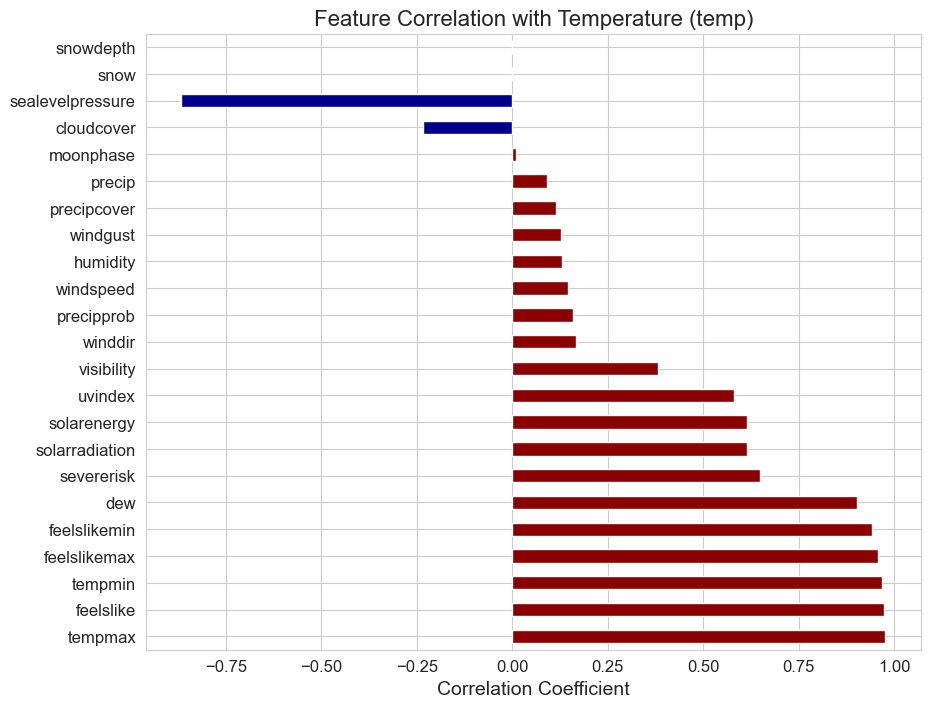

In [12]:
temp_corr = correlation_matrix['temp'].sort_values(ascending=False)

print("\nMối tương quan của các Features với Nhiệt độ (temp):")
print(temp_corr)

plt.figure(figsize=(10, 8))
temp_corr.drop('temp').plot(kind='barh', color=(temp_corr.drop('temp') > 0).map({True: 'darkred', False: 'darkblue'}))
plt.title('Feature Correlation with Temperature (temp)', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=14)
plt.show()